# EDA — Predicción de precios de viviendas (Ames Iowa Housing)
### Parte 2: Análisis exploratorio de los datos (EDA)

Este notebook desarrolla:
1. Estadística descriptiva y distribución de `SalePrice`
2. Identificación de valores faltantes, outliers y anomalías

## 0. Importación de librerías y carga de datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

df = pd.read_csv("../data/Ames_Iowa_Housing_Dataset.csv")
print("Dimensiones del dataset:", df.shape)
df.head()

Dimensiones del dataset: (2930, 82)


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.0,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.0,Unf,0.0,441.0,1080.0,GasA,Fa,Y,SBrkr,1656,0,0,1656,1.0,0.0,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960.0,Fin,2.0,528.0,TA,TA,P,210,62,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,NaN,0.0,Gd,TA,CBlock,TA,TA,No,ALQ,1065.0,Unf,0.0,1045.0,2110.0,GasA,Ex,Y,SBrkr,2110,0,0,2110,1.0,0.0,2,1,3,1,Ex,8,Typ,2,TA,Attchd,1968.0,Fin,2.0,522.0,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


## 1. Estadística descriptiva y distribución de `SalePrice`

`SalePrice` es la variable objetivo del proyecto. Analizamos sus estadísticos principales y su forma de distribución.

In [2]:
# Estadísticos descriptivos
desc = df['SalePrice'].describe()
print(desc)

print(f"\nAsimetría (skewness): {df['SalePrice'].skew():.2f}")
print(f"Curtosis: {df['SalePrice'].kurtosis():.2f}")

count      2930.000000
mean     180796.060068
std       79886.692357
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: SalePrice, dtype: float64

Asimetría (skewness): 1.74
Curtosis: 5.12


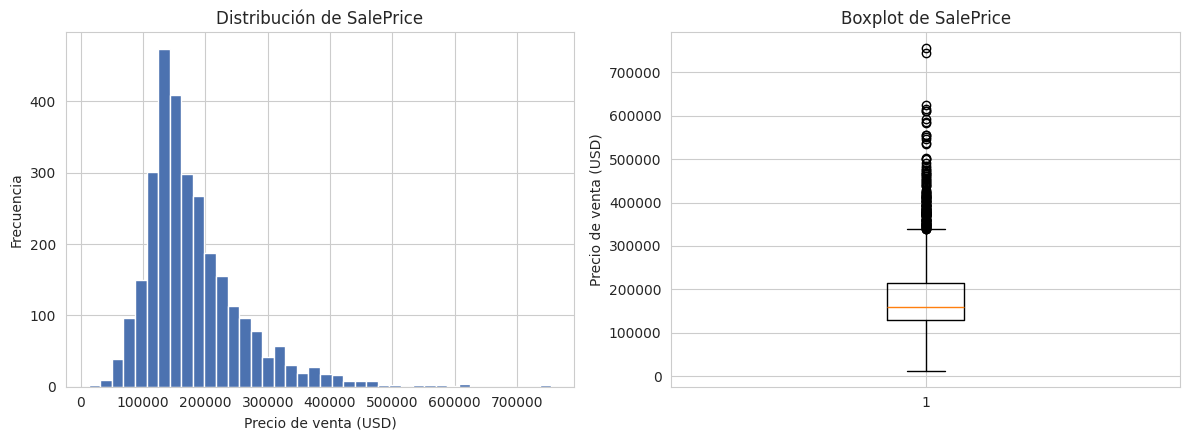

In [3]:
# Visualización: histograma + boxplot
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(df['SalePrice'], bins=40, color='#4C72B0', edgecolor='white')
axes[0].set_title('Distribución de SalePrice')
axes[0].set_xlabel('Precio de venta (USD)')
axes[0].set_ylabel('Frecuencia')

axes[1].boxplot(df['SalePrice'], vert=True)
axes[1].set_title('Boxplot de SalePrice')
axes[1].set_ylabel('Precio de venta (USD)')

plt.tight_layout()
plt.savefig('../images/saleprice_distribucion.png', dpi=130)
plt.show()

**Interpretación:**

La distribución de `SalePrice` presenta un **sesgo positivo marcado** (skewness ≈ 1.74). La mayoría de las viviendas
se concentra entre USD 100.000 y USD 220.000, mientras que una cola de propiedades de alto valor (hasta USD 755.000)
estira la distribución hacia la derecha. La media (≈ USD 180.796) es notablemente mayor que la mediana (USD 160.000),
lo que confirma la asimetría.

> Esto sugiere que, para el modelamiento posterior, podría convenir aplicar una **transformación logarítmica**
> sobre `SalePrice` para acercar su distribución a una normal.

## 2. Identificación de valores faltantes, outliers y anomalías

### 2.1 Valores faltantes

In [4]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0]
missing_df

,missing_count,missing_pct
Pool QC,2917,99.56
Misc Feature,2824,96.38
Alley,2732,93.24
Fence,2358,80.48
Mas Vnr Type,1775,60.58
Fireplace Qu,1422,48.53
Lot Frontage,490,16.72
Garage Qual,159,5.43
Garage Yr Blt,159,5.43
Garage Cond,159,5.43


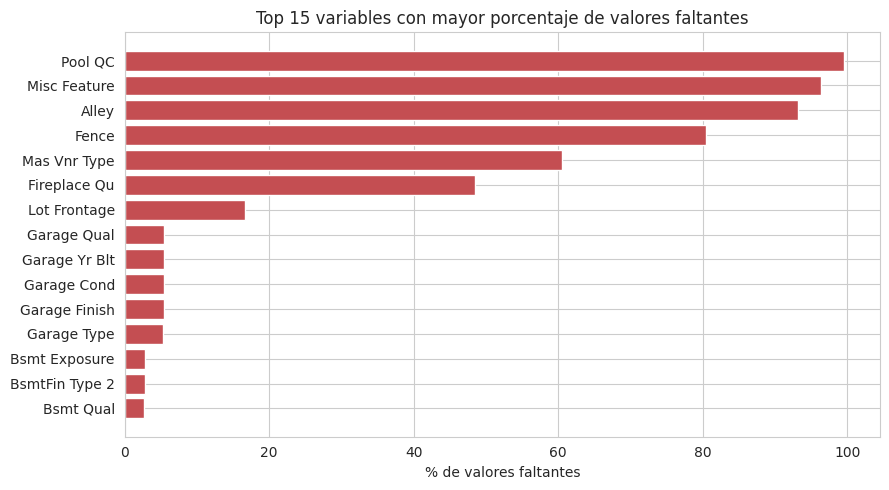

In [5]:
# Visualización de las variables con más valores faltantes
top_missing = missing_df.head(15)

plt.figure(figsize=(9,5))
plt.barh(top_missing.index[::-1], top_missing['missing_pct'][::-1], color='#C44E52')
plt.xlabel('% de valores faltantes')
plt.title('Top 15 variables con mayor porcentaje de valores faltantes')
plt.tight_layout()
plt.savefig('../images/valores_faltantes.png', dpi=130)
plt.show()

**Interpretación:**

En variables como `Pool QC`, `Alley`, `Fence`, `Garage*` y `Bsmt*`, el valor nulo **no representa un dato
perdido por error**, sino la **ausencia física del atributo** (ej. una casa sin piscina no tiene `Pool QC`,
una casa sin garaje no tiene `Garage Yr Blt`). Esto es clave para decidir la estrategia de imputación en
la Parte 3: no corresponde imputar con media/moda, sino con una categoría explícita como `"None"` o `0`.

`Lot Frontage` (16.72% de nulos) es distinto: parece ser información no registrada, por lo que requiere
una imputación más cuidadosa (ej. mediana agrupada por `Neighborhood`).

In [6]:
# Detalle de las dos variables clave: Lot Frontage y Garage Yr Blt
for col in ['Lot Frontage', 'Garage Yr Blt']:
    nulos = df[col].isnull().sum()
    print(f"--- {col} ---")
    print(df[col].describe())
    print(f"Nulos: {nulos} ({nulos/len(df)*100:.2f}%)\n")

--- Lot Frontage ---
count    2440.000000
mean       69.224590
std        23.365335
min        21.000000
25%        58.000000
50%        68.000000
75%        80.000000
max       313.000000
Name: Lot Frontage, dtype: float64
Nulos: 490 (16.72%)

--- Garage Yr Blt ---
count    2771.000000
mean     1978.132443
std        25.528411
min      1895.000000
25%      1960.000000
50%      1979.000000
75%      2002.000000
max      2207.000000
Name: Garage Yr Blt, dtype: float64
Nulos: 159 (5.43%)



### 2.2 Outliers (método IQR)

In [7]:
def detectar_outliers_iqr(serie):
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR
    outliers = serie[(serie < limite_inf) | (serie > limite_sup)]
    return outliers, limite_inf, limite_sup

for col in ['SalePrice', 'Lot Frontage']:
    outliers, low, high = detectar_outliers_iqr(df[col].dropna())
    print(f"--- {col} ---")
    print(f"Límites IQR: [{low:.1f}, {high:.1f}]")
    print(f"N° de outliers: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)\n")

--- SalePrice ---
Límites IQR: [3500.0, 339500.0]
N° de outliers: 137 (4.68%)

--- Lot Frontage ---
Límites IQR: [25.0, 113.0]
N° de outliers: 187 (6.38%)



**Interpretación:**

- `SalePrice`: **137 outliers (4.68%)** fuera del rango IQR [USD 3.500 – USD 339.500], concentrados en el
  extremo superior (viviendas de alto valor).
- `Lot Frontage`: **187 outliers (6.38%)**, principalmente en el extremo superior (valores de hasta 313 pies,
  muy por encima del rango típico de 25–113 pies).

### 2.3 Anomalías detectadas

In [8]:
# Anomalía en Garage Yr Blt: años fuera de rango razonable
anomalia_garage = df[df['Garage Yr Blt'] > 2020][['PID', 'Year Built', 'Year Remod/Add', 'Garage Yr Blt', 'Garage Type']]
anomalia_garage

,PID,Year Built,Year Remod/Add,Garage Yr Blt,Garage Type
2260,916384070,2006,2007,2207.0,Attchd


**Anomalía detectada:** el registro `PID 916384070` tiene `Garage Yr Blt = 2207`, un año que no existe en
el contexto del dataset (la vivienda fue construida en 2006 y remodelada en 2007). Es prácticamente seguro
que se trata de un **error de tipeo** (2007 registrado como 2207), y deberá corregirse en la Parte 3.

In [9]:
# Outlier clásico del dataset Ames: viviendas muy grandes con precio inconsistente
df[df['Gr Liv Area'] > 4000][['PID', 'Gr Liv Area', 'SalePrice']]

,PID,Gr Liv Area,SalePrice
1498,908154235,5642,160000
1760,528320050,4476,745000
1767,528351010,4316,755000
2180,908154195,5095,183850
2181,908154205,4676,184750


**Interpretación:** dos propiedades con `Gr Liv Area` superior a 4.000 pies² (4.316 y 4.476 pies²) se
vendieron en USD 745.000 y USD 755.000 — una combinación esperable de vivienda grande y precio alto.
Sin embargo, otra propiedad de **5.642 pies²** se vendió en solo **USD 160.000**, muy por debajo de lo
esperado para su tamaño. Este caso atípico ameritará revisión en la Parte 3 (podría tratarse de una venta
entre familiares o una condición particular de la propiedad no capturada por otras variables).

## Resumen de hallazgos (para la Parte 3)

- Aplicar transformación logarítmica a `SalePrice` para reducir la asimetría antes de modelar.
- Imputar con `"None"` / `0` las variables donde el nulo significa ausencia del atributo (`Pool QC`, `Alley`,
  `Fence`, `Garage*`, `Bsmt*`).
- Imputar `Lot Frontage` con una estrategia más cuidadosa (ej. mediana por `Neighborhood`).
- Corregir la anomalía de `Garage Yr Blt = 2207` (PID 916384070) → probablemente 2007.
- Revisar el tratamiento de los outliers de `SalePrice` y `Lot Frontage`, y decidir si se excluyen o se
  mantienen los casos atípicos de `Gr Liv Area` > 4000.